# Imports

In [29]:
%load_ext autoreload
%autoreload 2

import time

# Third-party libraries
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

# Local project imports
from eci.environment import Environment
from eci.plots import plot_belief_trajectory, plot_preference
from eci.utils import _extract_env_data_vectorized, get_voter_trajectory_data
from eci.voting_system.beliefs import _get_pref_belief_gap, _get_pref_candidate_gap
from eci.voting_system.decisions import _sample_choice

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Electoral Decision-Making
This tutorial simulates a decision making process where agents (voters) choose between candidates based on their preference and beliefs. Instead of voting randomly, agents reduce the gap between how they think the world is and they want it to be and the candidate that help reduce this.

## Setting up the Environment
The environement is made of agent which can be voter or candidate and they get preferences.
First, we initialize the simulation environment. In this example, we create a micro-world with 1 Voter and 2 Candidates evaluated on 2 distinct preference dimensions.

In [30]:
# Initialise environement
env = Environment(num_voters=1, num_candidates=2, num_preferences=2)

You can inspect the agents and get informations about them: Their preferences, if they are candidate or voter and others attributes that will be use in different scenario.

In [31]:
env.agents

[Voter(id=0, preferences={'mean': Array([0.8278444, 1.008174 ], dtype=float32), 'precision': Array([0.74241656, 0.6436357 ], dtype=float32)}, tonic_volatility=-1.9921076927620736, budget=100.0, perceived_outcome=None, vote_round_1=[], vote_round_2=[], softmax_probs_1=[], softmax_probs_2=[], dissatisfactions=[], trajectory=None, observation=None),
 Candidate(id=1, policy={'mean': Array([1.8334949 , 0.17660117], dtype=float32), 'precision': Array([0.4795505 , 0.71448344], dtype=float32)}, vote_count=0),
 Candidate(id=2, policy={'mean': Array([1.5208642, 1.7355175], dtype=float32), 'precision': Array([0.5000426, 0.8202698], dtype=float32)}, vote_count=0)]

## Visualizing the Agent
We can visualize the agent's internal model using a Hierarchical Gaussian Filter (HGF). Bottom Nodes ($x_0, x_1$): These represent observations per preference.Top Nodes ($x_2, ...$): These represent the agent's hidden beliefs and preferences.

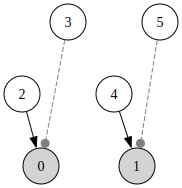

In [32]:
env.network.plot_network()

## Inspecting Preferences
An agent's preference is defined by two key parameters: 
Mean: The position of the preference/
Precision: The confidence in that preference (e.g., "I am very sure about this").
You can display the preference of your agent, by selecting from the environement which agent you want to plot.

In [33]:
# Get the preference for one agent (preference = (mean,precision)).
env.voters[0].preferences["mean"]
env.voters[0].preferences["precision"]

Array([0.74241656, 0.6436357 ], dtype=float32)

We can manually intervene in the simulation to test specific scenarios. Here, we force the Voter to strictly prefer the position [0, 0] (the center) with low precision [0.1, 0.1].

In [34]:
# Modify the preference.
env.voters[0].preferences["mean"] = jnp.array([0, 0])
env.voters[0].preferences["precision"] = jnp.array([0.1, 0.1])
env.voters[0]

Voter(id=0, preferences={'mean': Array([0, 0], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, tonic_volatility=-1.9921076927620736, budget=100.0, perceived_outcome=None, vote_round_1=[], vote_round_2=[], softmax_probs_1=[], softmax_probs_2=[], dissatisfactions=[], trajectory=None, observation=None)

Simultaneously, we position Candidate 1 at [1, 1] and Candidate 2 at [3, 3].

In [35]:
# Modify candidate policy.
env.candidates[0].policy["mean"] = jnp.array([1, 1])
env.candidates[0].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates[1].policy["mean"] = jnp.array([3, 3])
env.candidates[1].policy["precision"] = jnp.array([0.1, 0.1])
env.candidates

[Candidate(id=1, policy={'mean': Array([1, 1], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0),
 Candidate(id=2, policy={'mean': Array([3, 3], dtype=int32), 'precision': Array([0.1, 0.1], dtype=float32)}, vote_count=0)]

Then you can plot them

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_39916/528186673.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


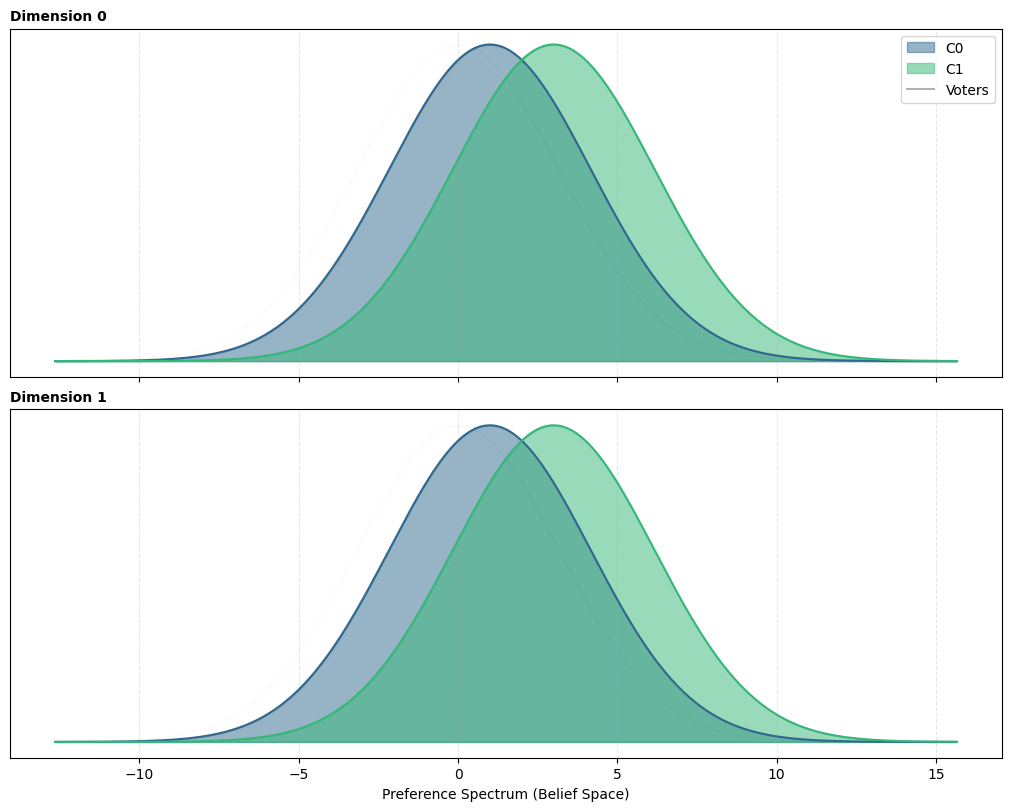

In [36]:
env._run_multi_agent_inference()
fig = plot_preference(env)
fig.show()

## Inspecting Beliefs
For each preference, agent get observation about the world and this contribute to form belief about the world on this specific preference.

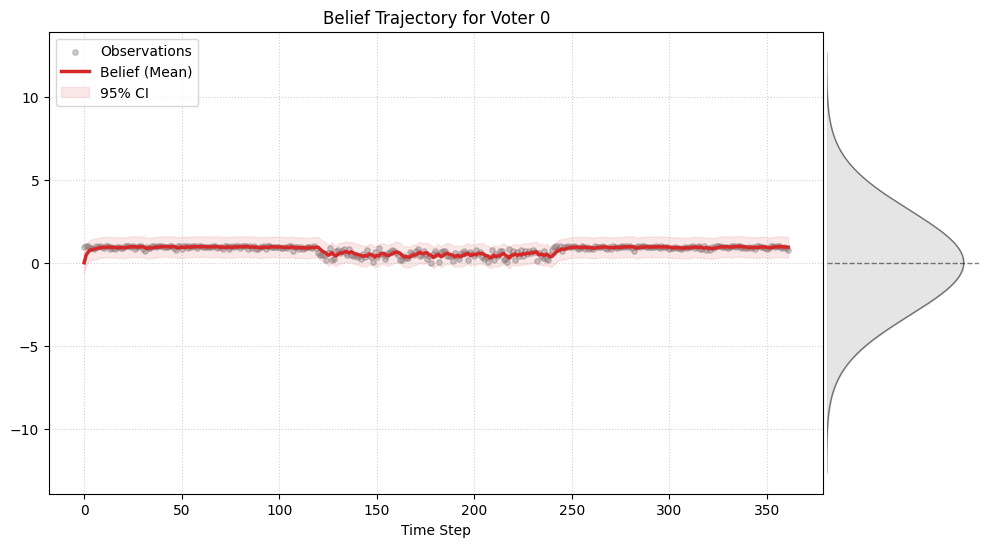

In [37]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

## The Decision Loop
Now that we have defined the agent's beliefs and preferences. The agent must transform its observations into a concrete action (the vote).

This process involves three mathematical steps, executed at every iteration:

In [38]:
# Get the data for all agents.
data = _extract_env_data_vectorized(env)
data

{'beliefs': {'mean': Array([[0.9312239 , 0.90360284]], dtype=float32),
  'precision': Array([[8.4441185, 8.375485 ]], dtype=float32)},
 'preferences': {'mean': Array([[0, 0]], dtype=int32),
  'precision': Array([[0.1, 0.1]], dtype=float32)},
 'candidates': {'mean': Array([[1, 1],
         [3, 3]], dtype=int32),
  'precision': Array([[0.1, 0.1],
         [0.1, 0.1]], dtype=float32)}}

1.  **Calculating the "Gap" (KL Divergence):**
    The agent measures the distance between its *preferences* (what it wants) and its *beliefs* about the world (what it perceives).
    * *Small Gap* = Low disatisfaction.
    * *Large Gap* = Hight disatisfaction.

In [39]:
pref_belief_gap = _get_pref_belief_gap(data)
pref_belief_gap

Array([3.5280495], dtype=float32)

1.  **Calculating the "Gap" (KL Divergence):**
    The agent measures the distance between its *preferences* (what it wants) and the candidate policy.
    * *Small Gap* = Low disatisfaction.
    * *Large Gap* = Hight disatisfaction.
Then we do the difference between theses two results

In [40]:
pref_candidate_gap = _get_pref_candidate_gap(data)
pref_candidate_gap

Array([[0.10000002, 0.9       ]], dtype=float32)

In [41]:
candidate_preferences = pref_belief_gap[:, jnp.newaxis] - pref_candidate_gap
candidate_preferences

Array([[3.4280496, 2.6280494]], dtype=float32)

Finally, we randomly select a winner following this probability distribution. This is the final act of voting.

In [42]:
# Do one vote.

key = jax.random.PRNGKey(int(time.time()))
# Split the JAX key for two separate random samples
key_round_1, key_round_2 = jax.random.split(key)

# Create mask for round 1 (all candidates are eligible)
mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)

# Sample round 1 vote
vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
vote_1

Array([1], dtype=int32)

We can also do it multiple times

In [43]:
# Do multiple vote for the same agent.
key = jax.random.PRNGKey(int(time.time()))
list_vote = []
num_votes = 100

for i in range(num_votes):
    key, key_iteration = jax.random.split(key)
    key_round_1, key_round_2 = jax.random.split(key_iteration)
    mask_round_1 = jnp.ones_like(candidate_preferences, dtype=bool)
    masked_preferences = jnp.where(mask_round_1, candidate_preferences, -jnp.inf)
    vote_1, softmax_probs_1 = _sample_choice(key_round_1, masked_preferences)
    list_vote.append(vote_1)
list_vote

[Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([0], dtype=int32),
 Array([1], dtype=int32),
 Array([1], dtype=int32),
 Array([1], 

The graph above displays the distribution of accumulated votes.
Here we can see in the result that the agent mostly vote for the candidate which reduce his disatifaction.

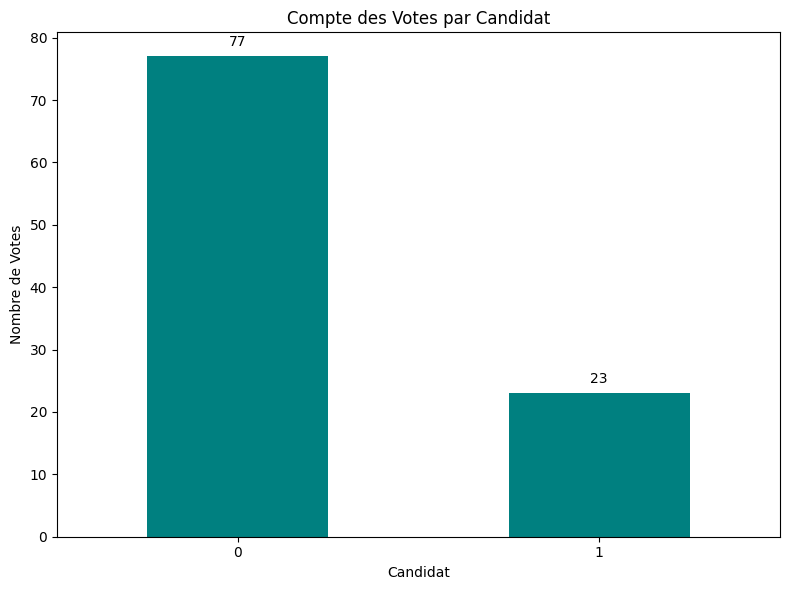

In [44]:
# Plot the votes.
df_votes = pd.DataFrame(list_vote, columns=["Candidat"])
vote_counts = df_votes["Candidat"].value_counts()
plt.figure(figsize=(8, 6))
ax = vote_counts.plot(kind="bar", color="teal")
plt.title("Compte des Votes par Candidat")
plt.ylabel("Nombre de Votes")
plt.xlabel("Candidat")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=5)
plt.tight_layout()
plt.savefig("vote_counts_bar_plot.png")

Then we can do it for multiple agent

In [57]:
NUM_VOTERS = 3  # Number of voters
NUM_CANDIDATES = 5  # Number of candidates
NUM_PREFERENCES = 4  # Number of preferences per voter
NUM_SIMULATIONS = 1  # Number of simulation steps (trajectories)

In [58]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS  # Number of simulations

In [59]:
env._run_multi_agent_inference()

In [60]:
data = _extract_env_data_vectorized(env)
data

{'beliefs': {'mean': Array([[0.9592074 , 0.97799414, 0.92267466, 0.9309213 ],
         [0.9592074 , 0.97799414, 0.92267466, 0.9309213 ],
         [0.9592074 , 0.97799414, 0.92267466, 0.9309213 ]], dtype=float32),
  'precision': Array([[8.350443, 8.394436, 8.368609, 8.373437],
         [8.350443, 8.394436, 8.368609, 8.373437],
         [8.350443, 8.394436, 8.368609, 8.373437]], dtype=float32)},
 'preferences': {'mean': Array([[0.31400657, 1.5033104 , 0.5138793 , 1.6400993 ],
         [1.8679295 , 1.0155959 , 0.24217987, 0.4377787 ],
         [0.06107831, 1.3693953 , 0.7683227 , 1.116863  ]], dtype=float32),
  'precision': Array([[0.5438616 , 0.52449644, 0.58987224, 0.8328968 ],
         [0.6919236 , 0.8123487 , 0.89460945, 0.6642865 ],
         [0.6263706 , 0.95109826, 0.66390365, 0.41392216]], dtype=float32)},
 'candidates': {'mean': Array([[0.5488138 , 0.9828923 , 1.7487075 , 0.64479303],
         [0.812943  , 0.6519952 , 0.0160358 , 0.8863611 ],
         [1.4859877 , 0.0391295 , 1.90

In [61]:
pref_belief_gap = _get_pref_belief_gap(data)
pref_belief_gap

Array([3.8253405, 3.5550783, 3.6536222], dtype=float32)

In [62]:
pref_candidate_gap = _get_pref_candidate_gap(data)
pref_candidate_gap

Array([[1.0353909 , 0.6350442 , 1.6285923 , 0.32867914, 1.3455245 ],
       [1.7928176 , 0.5595884 , 2.2828348 , 1.5558987 , 1.574266  ],
       [0.74810857, 0.76483667, 2.0714345 , 0.62347347, 0.80593187]],      dtype=float32)

In [63]:
preference_score_per_agent = pref_belief_gap[:, jnp.newaxis] - pref_candidate_gap
preference_score_per_agent

Array([[2.7899497, 3.1902962, 2.1967483, 3.4966614, 2.479816 ],
       [1.7622607, 2.9954898, 1.2722435, 1.9991796, 1.9808123],
       [2.9055135, 2.8887854, 1.5821877, 3.0301487, 2.8476903]],      dtype=float32)

In [52]:
preference_score_per_agent.shape

(100, 2)